<a href="https://colab.research.google.com/github/melyhorman/melyhorman.github.io/blob/main/Saas_pricing_Analyst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bagian Baru

#1 . Connect to Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#2 . Load **File**

In [2]:
import pandas as pd

df_master = pd.read_csv('/content/drive/MyDrive/FEB26_FSDANEXT_Bellatrix/Table Saas data.csv')
df_elastic = pd.read_csv('/content/drive/MyDrive/FEB26_FSDANEXT_Bellatrix/Elas Prep.csv')



In [3]:
df_master.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1754 entries, 0 to 1753
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   contract_id            1754 non-null   int64  
 1   leads_id               1754 non-null   int64  
 2   date                   1754 non-null   object 
 3   year                   1754 non-null   int64  
 4   year_month             1754 non-null   object 
 5   month                  1754 non-null   int64  
 6   quarter                1754 non-null   object 
 7   is_promo_month         1754 non-null   int64  
 8   cohort_month           860 non-null    float64
 9   subscription_type      1754 non-null   object 
 10  number_of_employee     1754 non-null   int64  
 11  original_price         1754 non-null   int64  
 12  price_per_employee     1754 non-null   int64  
 13  GMV                    1754 non-null   int64  
 14  discount_value         1754 non-null   int64  
 15  disc

In [4]:
df_elastic.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   year                    24 non-null     int64  
 1   quarter                 24 non-null     object 
 2   subscription_type       24 non-null     object 
 3   avg_price_per_employee  24 non-null     float64
 4   total_contract          24 non-null     int64  
 5   total_customers         24 non-null     int64  
 6   avg_discount            24 non-null     float64
 7   avg_company_size        24 non-null     float64
 8   total_revenue           24 non-null     int64  
 9   promo_price             24 non-null     int64  
 10  non_promo_price         24 non-null     int64  
 11  promo_contract          24 non-null     int64  
 12  non_promo_contract      24 non-null     int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 2.6+ KB


In [5]:
print(df_master.columns)

Index(['contract_id', 'leads_id', 'date', 'year', 'year_month', 'month',
       'quarter', 'is_promo_month', 'cohort_month', 'subscription_type',
       'number_of_employee', 'original_price', 'price_per_employee', 'GMV',
       'discount_value', 'discount_pct', 'is_discount_applied',
       'discount_rule_check', 'reten_flag', 'is_new_promo_customer',
       'discount_type_code', 'discount_type', 'month_discount',
       'industry_code', 'industry'],
      dtype='object')


In [6]:
print(df_elastic.columns)

Index(['year', 'quarter', 'subscription_type', 'avg_price_per_employee',
       'total_contract', 'total_customers', 'avg_discount', 'avg_company_size',
       'total_revenue', 'promo_price', 'non_promo_price', 'promo_contract',
       'non_promo_contract'],
      dtype='object')


#3 . Calculating Effective Discount per Contract

In [7]:
df_master['effective_discount'] = df_master['discount_value'] / df_master['original_price']

In [8]:
# 1. Distribusi
df_master['effective_discount'].value_counts()

# 2. Proporsi no discount
(df_master['effective_discount'] == 0).mean()

# 3. Segmentasi
df_master['discount_bucket'] = pd.cut(
    df_master['effective_discount'],
    bins=[-0.01, 0, 0.05, 0.1, 1],
    labels=['no_discount', 'low', 'medium', 'high']
)

df_master['discount_bucket'].value_counts()

,count
discount_bucket,
no_discount,1312
high,298
medium,144
low,0


In [9]:
df_master[['original_price','discount_value','effective_discount']].head(10)

,original_price,discount_value,effective_discount
0,15000,3000,0.2
1,15000,3000,0.2
2,15000,3000,0.2
3,15000,3000,0.2
4,15000,3000,0.2
5,15000,3000,0.2
6,15000,3000,0.2
7,15000,3000,0.2
8,15000,3000,0.2
9,15000,3000,0.2


In [10]:
df_master[['original_price','discount_value','effective_discount']].sample(5)

,original_price,discount_value,effective_discount
1234,25000,0,0.0
733,25000,5000,0.2
934,25000,5000,0.2
25,15000,3000,0.2
886,25000,5000,0.2


#4 . Sanity Chack

In [11]:
df_master['effective_discount'].describe()

,effective_discount
count,1754.000000
mean,0.042189
std,0.076422
min,0.000000
25%,0.000000
50%,0.000000
75%,0.100000
max,0.200000


In [12]:
df_master[['original_price', 'discount_value', 'effective_discount']].sample(5)

,original_price,discount_value,effective_discount
585,20000,0,0.0
1263,25000,0,0.0
379,15000,0,0.0
1622,25000,0,0.0
777,20000,0,0.0


In [13]:
df_master[df_master['original_price'] == 0]

,contract_id,leads_id,date,year,year_month,month,quarter,is_promo_month,cohort_month,subscription_type,...,discount_rule_check,reten_flag,is_new_promo_customer,discount_type_code,discount_type,month_discount,industry_code,industry,effective_discount,discount_bucket


In [14]:
df_master['effective_discount'].isna().sum()

np.int64(0)

#5 . Outlier Check

In [15]:
Q1 = df_master['effective_discount'].quantile(0.25)
Q3 = df_master['effective_discount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_master[(df_master['effective_discount'] < lower) |
          (df_master['effective_discount'] > upper)]

,contract_id,leads_id,date,year,year_month,month,quarter,is_promo_month,cohort_month,subscription_type,...,discount_rule_check,reten_flag,is_new_promo_customer,discount_type_code,discount_type,month_discount,industry_code,industry,effective_discount,discount_bucket


Findings : No Outlier

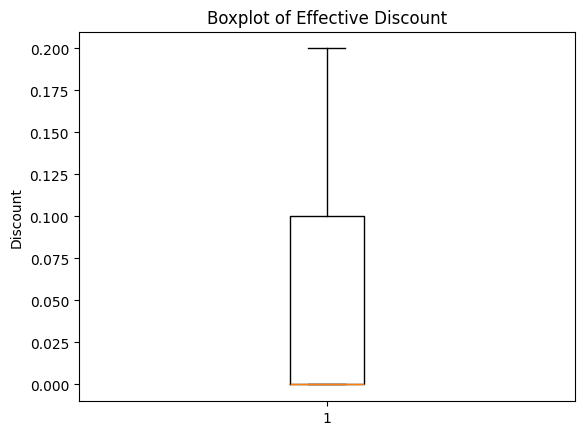

In [16]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(df_master['effective_discount'])
plt.title('Boxplot of Effective Discount')
plt.ylabel('Discount')
plt.show()

Findings:
 Most customers receive little to no discount, with promotional discounts applied selectively up to 20%

<Figure size 640x480 with 0 Axes>

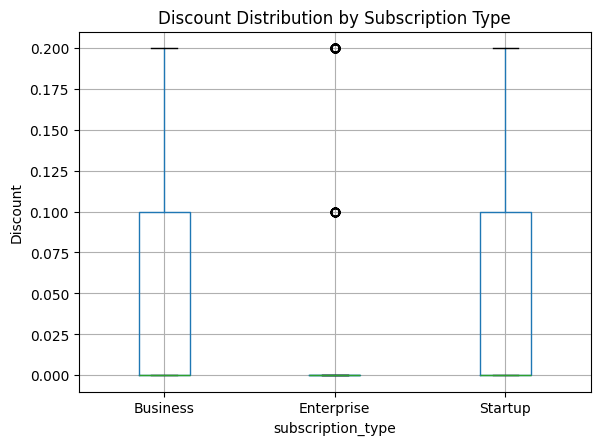

In [17]:
plt.figure()
df_master.boxplot(column='effective_discount', by='subscription_type')
plt.title('Discount Distribution by Subscription Type')
plt.suptitle('')
plt.ylabel('Discount')
plt.show()

Findings :
The absence of segment-specific outliers suggests that pricing policies are uniformly enforced across all customer segments.

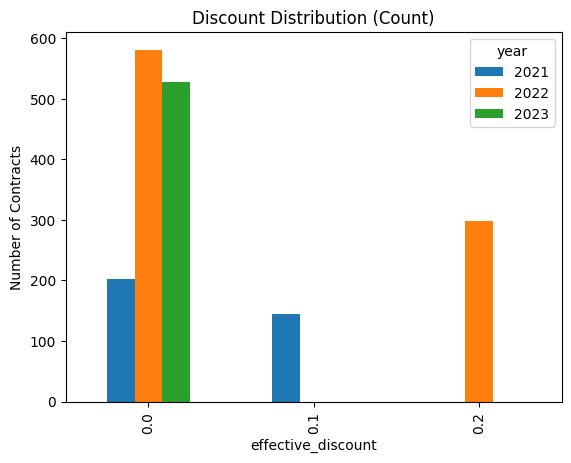

In [18]:
df_plot = df_master.groupby(['year', 'effective_discount']).size().reset_index(name='count')

df_plot_pivot = df_plot.pivot(index='effective_discount', columns='year', values='count')

df_plot_pivot.plot(kind='bar')
plt.title('Discount Distribution (Count)')
plt.ylabel('Number of Contracts')
plt.show()

Findings:
The introduction of 20% discounts likely contributed to higher observed elasticity, as customers became more responsive when exposed to stronger promotional incentives.

#6 . Create Promo flag

In [19]:
df_master = df_master[df_master['year'].isin([2021, 2022])]

In [20]:

df_master['is_promo'] = df_master['discount_pct'] > 0
# label
df_master['promo_type'] = df_master['is_promo'].map({
    True: 'promo',
    False: 'non_promo'
})

In [21]:
df_master['promo_type'].value_counts()

df_master.groupby('promo_type')['discount_pct'].describe()

,count,mean,std,min,25%,50%,75%,max
promo_type,,,,,,,,
non_promo,784.0,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0
promo,442.0,0.167421,0.04692,0.1,0.1,0.2,0.2,0.2


In [22]:

df_temp = df_master[df_master['year'].isin([2021, 2022])].copy()
df_temp['is_promo'] = df_temp['discount_pct'] > 0

# hitung jumlah per group
summary = df_temp.groupby(['year', 'is_promo']).size().reset_index(name='count')

# total per tahun
total_per_year = summary.groupby('year')['count'].transform('sum')

# hitung %
summary['percentage'] = summary['count'] / total_per_year * 100

# label biar readable
summary['promo_type'] = summary['is_promo'].map({
    True: 'promo',
    False: 'non_promo'
})

summary[['year', 'promo_type', 'count', 'percentage']]
pivot_summary = summary.pivot(
    index='year',
    columns='promo_type',
    values='percentage'
)

pivot_summary

promo_type,non_promo,promo
year,,
2021,58.501441,41.498559
2022,66.097838,33.902162


#7 . Aggregate Per Quarter

In [23]:
df_agg = df_master.groupby(
    ['year', 'quarter', 'subscription_type', 'promo_type']
).agg({
    'price_per_employee': 'mean',
    'contract_id': 'nunique'
}).reset_index()

df_agg = df_agg.rename(columns={
    'price_per_employee': 'price',
    'contract_id': 'quantity'
})

#8 . Pivot

In [24]:
pivot = df_agg.pivot_table(
    index=['subscription_type', 'quarter', 'promo_type'],
    columns='year',
    values=['price', 'quantity']
).reset_index()

In [25]:
pivot.columns = [
    f"{col[0]}_{col[1]}" if col[1] != '' else col[0]
    for col in pivot.columns
]

In [26]:
#RENAME
pivot = pivot.rename(columns={
    'price_2021': 'price_2021',
    'price_2022': 'price_2022',
    'quantity_2021': 'q_2021',
    'quantity_2022': 'q_2022'
})

#9 . Price Elasticity Calculation

In [27]:
pivot['pct_change_q'] = (
    (pivot['q_2022'] - pivot['q_2021']) /
    ((pivot['q_2021'] + pivot['q_2022']) / 2)
)

pivot['pct_change_p'] = (
    (pivot['price_2022'] - pivot['price_2021']) /
    ((pivot['price_2021'] + pivot['price_2022']) / 2)
)

pivot['elasticity'] = pivot['pct_change_q'] / pivot['pct_change_p']
pivot

,subscription_type,quarter,promo_type,price_2021,price_2022,q_2021,q_2022,pct_change_q,pct_change_p,elasticity
0,Business,Q1,non_promo,25000.0,25000.0,23.0,55.0,0.820513,0.000000,inf
1,Business,Q1,promo,22500.0,20000.0,17.0,22.0,0.256410,-0.117647,-2.179487
2,Business,Q2,non_promo,25000.0,25000.0,24.0,58.0,0.829268,0.000000,inf
3,Business,Q2,promo,22500.0,20000.0,17.0,30.0,0.553191,-0.117647,-4.702128
4,Business,Q3,non_promo,25000.0,25000.0,22.0,56.0,0.871795,0.000000,inf
5,Business,Q3,promo,22500.0,20000.0,15.0,38.0,0.867925,-0.117647,-7.377358
6,Business,Q4,non_promo,25000.0,25000.0,17.0,55.0,1.055556,0.000000,inf
7,Business,Q4,promo,22500.0,20000.0,13.0,48.0,1.147541,-0.117647,-9.754098
8,Enterprise,Q1,non_promo,15000.0,15000.0,9.0,32.0,1.121951,0.000000,inf
9,Enterprise,Q1,promo,13500.0,12000.0,6.0,11.0,0.588235,-0.117647,-5.000000


In [28]:
pivot = pivot[
    (pivot['pct_change_p'].abs() > 0.01) &
    (pivot['pct_change_q'].abs() > 0.01)
]

#10 . Summary Price Elasticity Result

In [29]:
pivot[['subscription_type', 'quarter', 'promo_type', 'elasticity']]

,subscription_type,quarter,promo_type,elasticity
1,Business,Q1,promo,-2.179487
3,Business,Q2,promo,-4.702128
5,Business,Q3,promo,-7.377358
7,Business,Q4,promo,-9.754098
9,Enterprise,Q1,promo,-5.000000
11,Enterprise,Q2,promo,-5.100000
13,Enterprise,Q3,promo,-5.173913
15,Enterprise,Q4,promo,-4.857143
17,Startup,Q1,promo,-6.696970
19,Startup,Q2,promo,-5.666667


In [30]:
pivot.groupby('promo_type')['elasticity'].mean()

,elasticity
promo_type,
promo,-5.612362


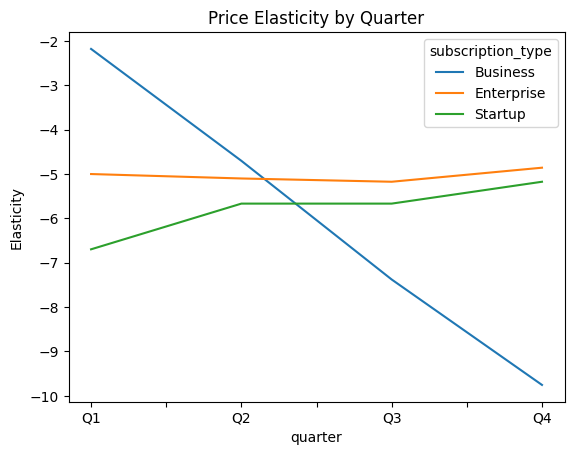

In [31]:
import matplotlib.pyplot as plt

pivot_plot = pivot.groupby(['quarter', 'subscription_type'])['elasticity'].mean().unstack()

pivot_plot.plot(kind='line')
plt.title('Price Elasticity by Quarter')
plt.ylabel('Elasticity')
plt.show()

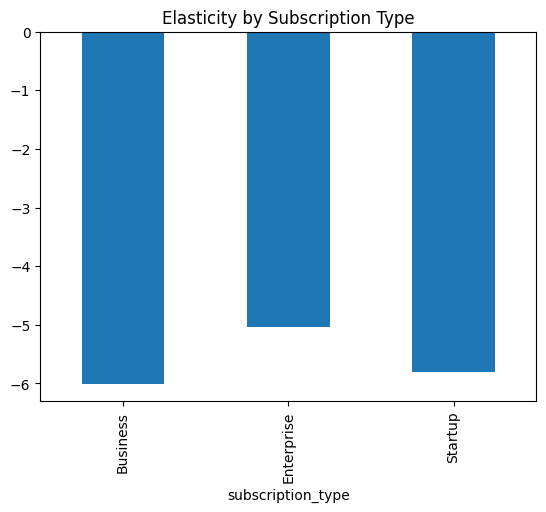

In [32]:
pivot.groupby('subscription_type')['elasticity'].mean().plot(kind='bar')
plt.title('Elasticity by Subscription Type')
plt.show()

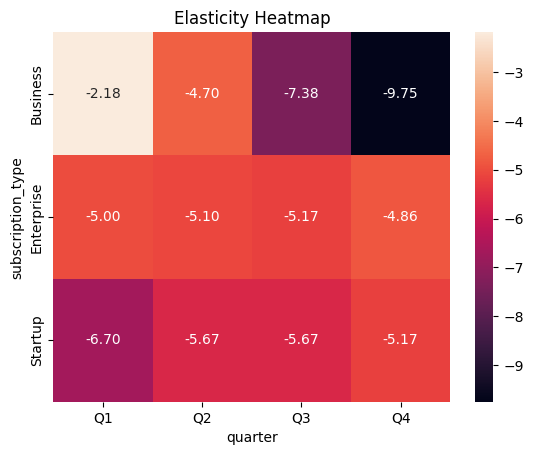

In [33]:
import seaborn as sns

heatmap_data = pivot.pivot_table(
    index='subscription_type',
    columns='quarter',
    values='elasticity'
)

sns.heatmap(heatmap_data, annot=True, fmt=".2f")
plt.title('Elasticity Heatmap')
plt.show()

Key Insights:
Business customers are increasingly price-sensitive, indicating a growing dependency on promotional pricing.
In contrast, Enterprise customers remain relatively stable, suggesting stronger value perception and lower reliance on discounts.

#11 . Employee Segment

In [34]:
# create employee size bucket
df_master['employee_bucket'] = pd.cut(
    df_master['number_of_employee'],
    bins=[0, 50, 100, 250, 500],
    labels=['small', 'medium', 'large', 'enterprise']
)
df_master['employee_bucket'].value_counts()

,count
employee_bucket,
large,436
small,427
enterprise,193
medium,170


In [35]:
df_breakdown = df_master.groupby([
    'year',
    'quarter',
    'subscription_type',
    'employee_bucket',
    'promo_type'
], observed=True).agg({
    'contract_id': 'nunique'
}).reset_index()

In [36]:
df_breakdown = df_breakdown.rename(columns={
    'contract_id': 'total_contract'
})

In [37]:
# total per segment (tanpa promo split)
df_breakdown['total_segment'] = df_breakdown.groupby([
    'year',
    'quarter',
    'subscription_type',
    'employee_bucket'

])['total_contract'].transform('sum')

# hitung %
df_breakdown['percentage'] = (
    df_breakdown['total_contract'] / df_breakdown['total_segment'] * 100
)



/tmp/ipykernel_65712/2942525653.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_breakdown['total_segment'] = df_breakdown.groupby([


In [38]:
print(df_breakdown.columns)

Index(['year', 'quarter', 'subscription_type', 'employee_bucket', 'promo_type',
       'total_contract', 'total_segment', 'percentage'],
      dtype='object')


In [39]:
df_breakdown.sort_values([
    'year', 'quarter', 'subscription_type', 'employee_bucket', 'promo_type'
])

,year,quarter,subscription_type,employee_bucket,promo_type,total_contract,total_segment,percentage
0,2021,Q1,Business,small,non_promo,22,34,64.705882
1,2021,Q1,Business,small,promo,12,34,35.294118
2,2021,Q1,Business,medium,non_promo,1,2,50.000000
3,2021,Q1,Business,medium,promo,1,2,50.000000
4,2021,Q1,Business,large,promo,4,4,100.000000
...,...,...,...,...,...,...,...,...
130,2022,Q4,Startup,medium,non_promo,16,25,64.000000
131,2022,Q4,Startup,medium,promo,9,25,36.000000
132,2022,Q4,Startup,large,non_promo,36,53,67.924528
133,2022,Q4,Startup,large,promo,17,53,32.075472


In [40]:
pivot_breakdown = df_breakdown.pivot_table(
    index=['year', 'quarter', 'subscription_type', 'employee_bucket'],
    columns='promo_type',
    values='percentage',
    observed=True
).reset_index()

pivot_breakdown



promo_type,year,quarter,subscription_type,employee_bucket,non_promo,promo
0,2021,Q1,Business,small,64.705882,35.294118
1,2021,Q1,Business,medium,50.000000,50.000000
2,2021,Q1,Business,large,NaN,100.000000
3,2021,Q1,Enterprise,large,57.142857,42.857143
4,2021,Q1,Enterprise,enterprise,62.500000,37.500000
...,...,...,...,...,...,...
70,2022,Q4,Enterprise,enterprise,68.750000,31.250000
71,2022,Q4,Startup,small,63.636364,36.363636
72,2022,Q4,Startup,medium,64.000000,36.000000
73,2022,Q4,Startup,large,67.924528,32.075472


In [41]:
num_cols = pivot_breakdown.select_dtypes(include='number').columns

pivot_breakdown[num_cols] = pivot_breakdown[num_cols].fillna(0)
pivot_breakdown

promo_type,year,quarter,subscription_type,employee_bucket,non_promo,promo
0,2021,Q1,Business,small,64.705882,35.294118
1,2021,Q1,Business,medium,50.000000,50.000000
2,2021,Q1,Business,large,0.000000,100.000000
3,2021,Q1,Enterprise,large,57.142857,42.857143
4,2021,Q1,Enterprise,enterprise,62.500000,37.500000
...,...,...,...,...,...,...
70,2022,Q4,Enterprise,enterprise,68.750000,31.250000
71,2022,Q4,Startup,small,63.636364,36.363636
72,2022,Q4,Startup,medium,64.000000,36.000000
73,2022,Q4,Startup,large,67.924528,32.075472


In [42]:
THANK YOU

SyntaxError: invalid syntax (482129816.py, line 1)